In [1]:
import pandas as pd
import numpy as np  

import matplotlib.pyplot as plt

from gingado.utils import get_timefeat, TemporalFeatureTransformer
from gingado.datasets import load_lr_tanzania_data

from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from keras.callbacks import EarlyStopping
from keras.models import Model
from keras.layers import LSTM, Dense, Input, Average, Masking
from keras.optimizers import Adam

from sklearn import set_config

# Set the global configuration to output pandas DataFrames
set_config(transform_output="pandas")


2025-01-16 10:14:51.836457: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-16 10:14:51.876784: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-16 10:14:52.549676: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
data = load_lr_tanzania_data(wide_format=False, datetime_index=True)

for freq, df in data.items():
    print(f"Frequency: {freq}, data shape: {df.shape}")

display(data['W'].head())
display(data['ME'].head())


Frequency: W, data shape: (20347, 27)
Frequency: ME, data shape: (4693, 241)


,INSTITUTIONCODE,01_CURR_ACC,02_TIME_DEPOSIT,03_SAVINGS,04_OTHER_DEPOSITS,05_BANKS_DEPOSITS,06_BORROWING_FROM_PUBLIC,07_INTERBANKS_LOAN_PAYABLE,08_CHEQUES_ISSUED,09_PAY_ORDERS,...,17_OTHER DEPOSITS,18_BANKS_TZ,19_BANKS_ABROAD,20_CHEQUES_ITEMS_FOR_CLEARING,21_INTERBANK_LOANS,22_TREASURY_BILLS,23_OTHER_GOV_SECURITIES,24_FOREIGN_CURRENCY,25_COMMERCIAL_BILLS,26_PROMISSORY_NOTES
REPORTINGDATE,,,,,,,,,,,,,,,,,,,,,
2010-01-15,B5014,3.991095e+10,8.525043e+09,1.795650e+10,1052155.45,0.0,0.0,1.557078e+09,1.981911e+08,2.986424e+08,...,1.500000e+09,2.040362e+08,6.084783e+09,1.466508e+09,1.441456e+10,2.906552e+10,0.0,0.0,3.383128e+09,1.071797e+08
2010-01-22,B5014,4.080184e+10,8.560163e+09,1.811616e+10,1052155.45,0.0,0.0,1.533282e+09,2.553601e+08,1.720941e+09,...,1.500000e+09,2.040362e+08,6.084783e+09,1.466508e+09,1.441456e+10,2.906552e+10,0.0,0.0,3.383128e+09,1.071797e+08
2010-01-29,B5014,3.765654e+10,7.780012e+09,2.009096e+10,1052155.45,0.0,0.0,1.499455e+09,1.779066e+08,2.296760e+08,...,1.500000e+09,2.040362e+08,6.084783e+09,1.466508e+09,1.441456e+10,2.906552e+10,0.0,0.0,3.383128e+09,1.071797e+08
2010-02-05,B5014,4.358491e+10,7.636494e+09,1.834680e+10,1052155.45,0.0,0.0,1.486844e+09,7.642781e+07,-5.985489e+08,...,1.500000e+09,2.040362e+08,6.084783e+09,1.466508e+09,1.441456e+10,2.906552e+10,0.0,0.0,3.383128e+09,1.071797e+08
2010-02-12,B5014,4.198509e+10,7.603740e+09,1.827224e+10,1052155.45,0.0,0.0,1.669462e+09,8.905947e+07,-6.895085e+07,...,1.500000e+09,2.040362e+08,6.084783e+09,1.466508e+09,1.441456e+10,2.906552e+10,0.0,0.0,3.383128e+09,1.071797e+08


,INSTITUTIONCODE,F001_ASSET_CASH,F002_ASSET_BAL_BOT,F003_ASSET_BAL_BOT_SMR,F004_ASSET_BAL_BOT_CURRENT_ACCOUNT,F005_ASSET_BAL_BOT_OTHERS,F006_ASSET_BAL_OTHER_BANKS,F007_ASSET_BAL_OTHER_BANKS_TZ,F008_ASSET_BAL_OTHER_BANKS_ABROAD,F009_ASSET_BAL_OTHER_BANKS_ABROAD_FIXED_INV,...,EWAQ_Capital,EWAQ_NPL,EWAQ_GrossLoans,EWAQ_LargeExposures,EWAQ_NPLsNetOfProvisions,EWAQ_NPLsNetOfProvisions2CoreCapital,EWAQ_NPLs2GrossLoans,EWAQ_AssetsQualityRating,EWAQ_Loans,MLA_CLASS
REPORTINGDATE,,,,,,,,,,,,,,,,,,,,,
2010-01-31,B5412,9.570422e+09,5.260077e+10,3.700000e+10,1.560077e+10,0.0,1.348740e+11,1.622160e+10,1.186520e+11,8.254988e+10,...,9.514540e+10,1.951219e+09,1.274810e+11,7.137633e+10,903220975.0,0.0095,0.0153,1.0,NaN,high
2010-02-28,B5412,6.996645e+09,3.554718e+10,3.200000e+10,3.547185e+09,0.0,1.482240e+11,7.535208e+08,1.474710e+11,1.161860e+11,...,9.595342e+10,1.954516e+09,1.251520e+11,7.831967e+10,904869349.0,0.0094,0.0156,1.0,NaN,high
2010-03-31,B5412,8.689629e+09,3.744132e+10,3.350000e+10,3.941316e+09,0.0,1.621370e+11,5.570919e+09,1.565660e+11,4.158973e+10,...,9.864602e+10,1.979268e+09,1.284300e+11,7.846886e+10,917245663.0,0.0093,0.0154,1.0,NaN,high
2010-04-30,B5412,6.811311e+09,3.527009e+10,3.250000e+10,2.770089e+09,0.0,2.244100e+11,8.739334e+09,2.156710e+11,1.071620e+11,...,9.960755e+10,2.014398e+09,1.286710e+11,8.986596e+10,934810301.0,0.0094,0.0157,1.0,NaN,high
2010-05-31,B5412,9.160128e+09,4.927299e+10,3.982500e+10,9.447986e+09,0.0,1.893920e+11,1.524899e+09,1.878670e+11,1.272350e+11,...,1.007330e+11,2.081954e+09,1.319650e+11,8.567217e+10,968588451.0,0.0096,0.0158,1.0,NaN,high


Use all weekly data and the monthly MLA as a target. In addition, also include the lags of the monthly MLA with the data.
To get started, start with data for one bank. The original paper mentions B5015 and B5912 as the largest banks, so take one of those.


In [3]:
bank_code = "B5015"

data["ME"] = data["ME"][["MLA", "INSTITUTIONCODE"]]

for freq, df in data.items():
    mask = df["INSTITUTIONCODE"] == bank_code
    data[freq] = df[mask].drop(columns=["INSTITUTIONCODE"])




In [4]:
from gingado.utils import Lag

Lag(lags=1).fit_transform(data["ME"])
data["ME"] = data["ME"].join(Lag(lags=1).fit_transform(data["ME"]))
data["ME"]

/home/jdamp/code/gingado/venv/lib/python3.10/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/home/jdamp/code/gingado/venv/lib/python3.10/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/home/jdamp/code/gingado/venv/lib/python3.10/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/home/jdamp/code/gingado/venv/lib/

,MLA,MLA_lag_1
REPORTINGDATE,,
2010-01-31,59.18,NaN
2010-02-28,61.08,59.18
2010-03-31,62.51,61.08
2010-04-30,62.59,62.51
2010-05-31,62.06,62.59
...,...,...
2021-08-31,26.63,26.95
2021-09-30,27.59,26.63
2021-10-31,29.87,27.59


In [5]:
# Select target
y = data["ME"].loc[:, ["MLA"]]
data["ME"] = data["ME"].drop(columns=["MLA"]).dropna() # NA in first date introduced by lag

In [6]:
# There is a particular data with null values for certain variables
nan_dates = data["W"][data["W"].isnull().any(axis=1)].index
print(f"Dates with NaN values: {nan_dates.tolist()}")
null_columns = data["W"].columns[data["W"].isnull().any()]
print(f"Columns with null values: {null_columns.tolist()}")

# Address this by interpolation:

data["W"] = data["W"].interpolate("linear")

Dates with NaN values: [Timestamp('2011-10-14 00:00:00')]
Columns with null values: ['13_CASH', '14_CURRENT_ACC', '15_SMR_ACC', '16_FOREIGN CURRENCY', '17_OTHER DEPOSITS', '18_BANKS_TZ', '19_BANKS_ABROAD', '20_CHEQUES_ITEMS_FOR_CLEARING', '21_INTERBANK_LOANS', '22_TREASURY_BILLS', '23_OTHER_GOV_SECURITIES', '24_FOREIGN_CURRENCY', '25_COMMERCIAL_BILLS', '26_PROMISSORY_NOTES']


Explicitly check that we have handled all null values properly:

In [7]:
assert not data["ME"].isnull().values.any(), "There are NaN values in data['W']"
assert not data["W"].isnull().values.any(), "There are NaN values in data['W']"

In [8]:
# Calculate the split index
split_index = len(data["W"]) * 99 // 100

# Find the corresponding date
split_date = data["W"].index[split_index]

print(f"The date that splits the DataFrame into a 2:1 ratio is: {split_date}")

The date that splits the DataFrame into a 2:1 ratio is: 2021-11-19 00:00:00


In [9]:
# Split into train and test samples

X_train = {}
X_test = {}
y_train = y.loc[y.index < split_date]
y_test = y.loc[y.index >= split_date]
for freq, df in data.items():
   X_train[freq] = df.loc[df.index < split_date]
   X_test[freq] = df.loc[df.index >= split_date]



In [10]:
# Scale the data:
from sklearn.preprocessing import StandardScaler
scalers = {}
X_train_norm = {}
X_test_norm = {}
for freq, df in X_train.items():
    scalers[freq] = StandardScaler().fit(df)
    X_train_norm[freq] = scalers[freq].transform(X_train[freq])
    X_test_norm[freq] = scalers[freq].transform(X_test[freq])

target_scaler = StandardScaler()
y_train_norm = target_scaler.fit_transform(y_train)
y_test_norm = target_scaler.transform(y_test)    

In [11]:
# Create further sub-splits:
from collections import defaultdict
from sklearn.model_selection import TimeSeriesSplit
from gingado.utils import pad_sequences


def process_fold(
        data: dict[str, pd.DataFrame],
        y: pd.Series, split: pd.DatetimeIndex,
        max_lags: dict[str, int],
        timedim: bool = True
    ):
    X_split = defaultdict(list)
    y_split = []
    for sample_date in split:
        
        for freq in data:
            # Select data up to the sample date and pad if necessary
            dates = data[freq][:sample_date].index[:-1]
            data_to_pad = data[freq].loc[dates]
            padded = pad_sequences(data_to_pad, max_lags[freq], use_timedim=timedim)
            X_split[freq].append(padded)
        y_split.append([y.loc[sample_date]])
    for freq in X_split:
        X_split[freq] = np.squeeze(X_split[freq])
    return X_split, np.array(y_split)


In [12]:

max_lags = {"ME": 3, "W": 12}

tscv = TimeSeriesSplit(n_splits=2)
timedim = True

cv_dates = [
    (y.index[m], y.index[n]) for m, n in tscv.split(y_train_norm)
]

X_split_train = {}
y_split_train = {}
X_split_val = {}
y_split_val = {}

for n, (train_split, val_split) in enumerate(cv_dates):
    XX, yy = process_fold(X_train_norm, y_train_norm, train_split, max_lags, timedim)
    X_split_train[n] = XX
    y_split_train[n] = yy

    XX, yy =  process_fold(X_train_norm, y_train_norm, val_split, max_lags, timedim)
    X_split_val[n] = XX
    y_split_val[n] = yy

In [13]:
print(f"Weekly data: (b, t, f) = {X_split_train[0]['W'].shape}")
print(f"Monthly data: (b, t, f) = {X_split_train[0]['ME'].shape}")

nan_counts = {freq: np.isnan(X_split_train[0][freq]).sum() for freq in X_split_train[0]}

Weekly data: (b, t, f) = (48, 12, 26)
Monthly data: (b, t, f) = (48, 3)


In [14]:
# Create a simple LSTM model using keras that can process two multivariate time series of different frequencies and combines them
# into a single prediction
# The model will have two LSTM layers, one for each time series, and a Dense layer that combines the output of the two LSTM layers
dim = 1
# Define the input layers

freqs = ["W", "ME"]

inputs = {
    freq: Input(shape=(None, data[freq].shape[1]), name=freq) for freq in freqs}
lstm_outputs = []
for freq, inp in inputs.items():
    mask = Masking(mask_value=0.0, name=f"mask_freq_{freq}")(inp)
    lstm = LSTM(dim, return_sequences=False, dropout=0.2, return_state=False, name=f"lstm_freq_{freq}")(mask)
    lstm_outputs.append(lstm)
combined = Average(name="lstm_combined")(lstm_outputs)
out = Dense(1, activation='linear', name="dense_out")(combined)

lstm_model = Model(inputs=inputs, outputs=out)
lstm_model.compile(optimizer=Adam(1e-2), loss='mean_squared_error')
lstm_model.summary()




Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ W (InputLayer)      │ (None, None, 26)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ME (InputLayer)     │ (None, None, 1)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None, 26)  │          0 │ W[0][0]           │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, None, 1)   │          0 │ ME[0][0]          │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask_freq_W         │ (None, None, 26)  │          0 │ W[0][0]           │
│ (Masking)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, None)      │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask_freq_ME        │ (None, None, 1)   │          0 │ ME[0][0]          │
│ (Masking)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_1 (Any)         │ (None, None)      │          0 │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_freq_W (LSTM)  │ (None, 1)         │        112 │ mask_freq_W[0][0… │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_freq_ME (LSTM) │ (None, 1)         │         12 │ mask_freq_ME[0][… │
│                     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_combined       │ (None, 1)         │          0 │ lstm_freq_W[0][0… │
│ (Average)           │                   │            │ lstm_freq_ME[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_out (Dense)   │ (None, 1)         │          2 │ lstm_combined[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 126 (504.00 B)

 Trainable params: 126 (504.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
from gingado.estimators import KerasEstimator

In [25]:
estimator = KerasEstimator(
    lstm_model, fit_ar_model=True, lags=3
)

In [26]:
estimator.model

<Functional name=functional, built=True>

In [27]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10)

estimator.fit(
    X_split_train[1],
    y_split_train[1],
    validation_data=(X_split_val[1], y_split_val[1]),
    epochs=50,
    batch_size=8,
    shuffle=True,
    callbacks=[early_stopping]
)

Epoch 1/50


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.9205 - val_loss: 2.2061
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.6821 - val_loss: 1.8751
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.8324 - val_loss: 1.7430
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.6518 - val_loss: 1.8902
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.4724 - val_loss: 1.8298
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.4628 - val_loss: 1.7347
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.8584 - val_loss: 1.5716
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.4299 - val_loss: 1.5558
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2849 - val_loss: 1.5640
Epoch 10/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.3309 - val_loss: 1.6807
Epoch 11/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.9776 - val_loss: 1.6755
Epoch 12/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2943 - val_l

KerasEstimator(fit_ar_model=True, lags=3,
               model=<Functional name=functional, built=True>)

Text(0.5, 1.0, 'Training and Validation Loss')

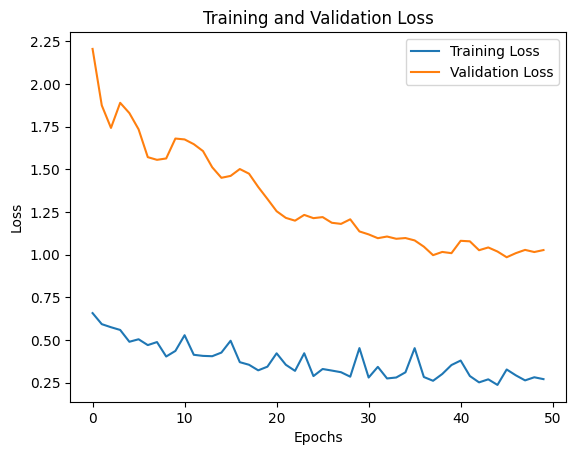

In [28]:
# Plot the training and validation loss
plt.plot(estimator.history.history['loss'], label='Training Loss')
plt.plot(estimator.history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


Text(0.5, 0.98, 'Multi-frequency data, LSTM model')

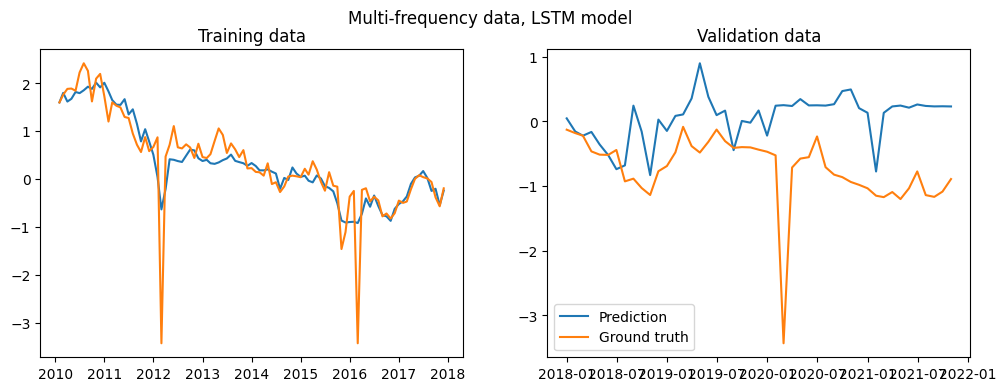

In [29]:
train_dates = cv_dates[1][0]
val_dates = cv_dates[1][1]
pred_train = lstm_model.predict(X_split_train[1])
pred = lstm_model.predict(X_split_val[1])


fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].set_title("Training data")
ax[0].plot(train_dates, pred_train, label="Prediction")
ax[0].plot(train_dates, y_split_train[1].squeeze(), label="Ground truth")

ax[1].set_title("Validation data")
ax[1].plot(val_dates, pred, label="Prediction")
ax[1].plot(val_dates, y_split_val[1].squeeze(), label="Ground truth")
plt.legend()
plt.suptitle("Multi-frequency data, LSTM model")

# Predict using a simple AR model with 3 lags

In [30]:
estimator.ar_model

NameError: name 'ar_pred_train' is not defined

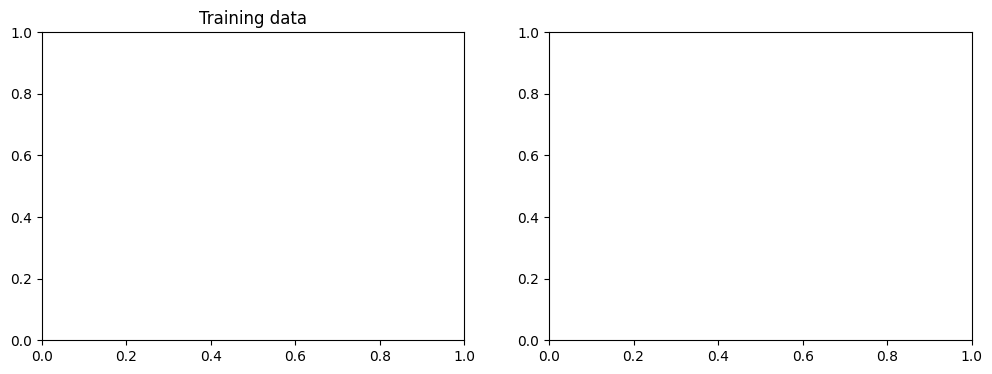

In [22]:
from statsmodels.tsa.ar_model import AutoReg

model = AutoReg(y_split_train[1], lags=3)
model_fit = model.fit()
model_fit.summary()

ar_pred_train = model_fit.predict(start=0, end=len(y_split_train[1])-1)
# Make predictions on the test set using real previous values
predictions = []
history = np.squeeze(y_split_train[1])  # Start with the training data

for t in range(len(y_split_val[1])):
    # Predict the next value based on the last 3 actual values
    lag_values = history[-3:]  # Get the last 3 values
    yhat = model_fit.params[0] + sum(model_fit.params[i + 1] * lag_values[-(i + 1)] for i in range(3))
    predictions.append(yhat)
    # Append the actual test value to history (as it becomes part of the known data)
    history = np.append(history, y_split_val[1][t])


val_dates = cv_dates[1][1]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].set_title("Training data")
ax[0].plot(cv_dates[1][0], ar_pred_train, label="AR Prediction")
ax[0].plot(cv_dates[1][0], y_split_train[1].squeeze(), label="Ground truth")
ax[0].legend()


ax[1].set_title("Validation data")
ax[1].plot(val_dates, predictions, label="AR Prediction")
ax[1].plot(val_dates, y_split_val[1].squeeze(), label="Ground truth")
plt.legend()
plt.suptitle("Univariate data, autoregressive model")